<a href="https://colab.research.google.com/github/dhruvidarji1/Phishing-Email-Prediction-Models/blob/main/MultinomialNaiveBayes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Install and import the libraries

In [204]:
!pip install -q datasets

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

from datasets import load_dataset

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

Load the dataset

In [ ]:
dataset = load_dataset(
    "simlab-vs/meajor_cleaned_preprocessed"
)

print(dataset)

DatasetDict({
    train: Dataset({
        features: ['sender', 'sender_domain', 'receiver', 'receiver_domain', 'date', 'subject', 'content_types', 'body', 'urls', 'url_count', 'url_length_max', 'url_length_avg', 'url_subdom_max', 'url_subdom_avg', 'attachment_count', 'has_attachments', 'attachment_types', 'language', 'source', 'label'],
        num_rows: 108685
    })
})


In [ ]:
df = dataset["train"].to_pandas()

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (108685, 20)


,sender,sender_domain,receiver,receiver_domain,date,subject,content_types,body,urls,url_count,url_length_max,url_length_avg,url_subdom_max,url_subdom_avg,attachment_count,has_attachments,attachment_types,language,source,label
0,d66e9e64b006d6bca649f1c945129c42c43836872b2ead...,enron.com,35c5a9fb9fba3b8737ed7cef2a87e427a73db4fca85f6b...,enron.com,2001-06-29 09:37:04-05:00,[ORGANIZATION] failover plan.,text/plain,"Hi [NAME], \n\nTonight we are rolling out a n...",None,0.0,0.0,0.0,0.0,0.0,0.0,False,None,en,trec5,0.0
1,0907d5c64598aa2639154ed4e1556be615669e40052a1f...,enron.com,aa2c35499eae5999bf6080453cc719a891da2bb0c3803d...,enron.com,2001-06-29 08:39:30-05:00,RE: Intranet Site,text/plain,"[NAME] r these new?\tIntranet Site\n\n[NAME],\...",http://eastpower.dev.corp.enron.com/summary/pj...,3.0,60.0,58.0,3.0,3.0,0.0,False,None,en,trec5,0.0
2,7c3201a5ff8c5985218f1e3f11e330dc0242bbd28c6c20...,enron.com,a736837579feb601fbf6c0657d3d93689774afa6491bb9...,enron.com;enron.com,2001-06-29 10:35:17-05:00,FW: [ORGANIZATION] Company information,text/plain,"[NAME]/[NAME],\n\nWe are currently trading und...",None,0.0,0.0,0.0,0.0,0.0,0.0,False,None,en,trec5,0.0
3,8531d54a169c4af106b9ea2165d4986b8cc10fc0a6bb9b...,enron.com,765a3ec4a67e40118d22de5729b05d090a1b59cb443bf6...,enron.com;enron.com,2001-06-29 10:40:02-05:00,New Master Physical,text/plain,[NAME] and [NAME] -\n\nAttached is a worksheet...,None,0.0,0.0,0.0,0.0,0.0,0.0,False,None,en,trec5,0.0
4,7c3201a5ff8c5985218f1e3f11e330dc0242bbd28c6c20...,enron.com,ce418c97ac415706338972e1dbbd99ebb8c617b5c937a3...,enron.com;enron.com;enron.com,2001-06-29 10:48:00-05:00,FW: [ORGANIZATION]/Mirant GISB,text/plain,FYI. Below is a copy of my communication with ...,None,0.0,0.0,0.0,0.0,0.0,0.0,False,None,en,trec5,0.0


Inspect the dataset

In [ ]:
print(df.columns.tolist())
print()
print(df["label"].value_counts())
print()
print(df[["subject", "body", "label"]].head())

['sender', 'sender_domain', 'receiver', 'receiver_domain', 'date', 'subject', 'content_types', 'body', 'urls', 'url_count', 'url_length_max', 'url_length_avg', 'url_subdom_max', 'url_subdom_avg', 'attachment_count', 'has_attachments', 'attachment_types', 'language', 'source', 'label']

label
0.0    60650
1.0    48034
Name: count, dtype: int64

                                  subject  \
0           [ORGANIZATION] failover plan.   
1                       RE: Intranet Site   
2  FW: [ORGANIZATION] Company information   
3                     New Master Physical   
4          FW: [ORGANIZATION]/Mirant GISB   

                                                body  label  
0  Hi [NAME],  \n\nTonight we are rolling out a n...    0.0  
1  [NAME] r these new?\tIntranet Site\n\n[NAME],\...    0.0  
2  [NAME]/[NAME],\n\nWe are currently trading und...    0.0  
3  [NAME] and [NAME] -\n\nAttached is a worksheet...    0.0  
4  FYI. Below is a copy of my communication with ...    0.0  


In [ ]:
print(df["label"].unique())

[ 0.  1. nan]


Remove unnecessary fields: sender, receiver, date, and language

In [ ]:
df = df.drop(columns=["sender", "receiver", "date", "language"])

print(df.columns.tolist())

['sender_domain', 'receiver_domain', 'subject', 'content_types', 'body', 'urls', 'url_count', 'url_length_max', 'url_length_avg', 'url_subdom_max', 'url_subdom_avg', 'attachment_count', 'has_attachments', 'attachment_types', 'source', 'label']


Check for missing values

In [ ]:
print(df[["subject", "body", "label"]].isnull().sum())

subject    1455
body          1
label         1
dtype: int64


In [ ]:
df["subject"] = df["subject"].fillna("")
df["body"] = df["body"].fillna("")

In [ ]:
df = df.dropna(subset=["label"])
df["label"] = df["label"].astype(int)

## Engineering Features

Sender Domain Length

In [ ]:
df["sender_domain_length"] = (
    df["sender_domain"]
    .fillna("")
    .str.len()
)

df[["sender_domain", "sender_domain_length"]].head()


,sender_domain,sender_domain_length
0,enron.com,9
1,enron.com,9
2,enron.com,9
3,enron.com,9
4,enron.com,9


Subject Length

In [ ]:
df["subject_length"] = (
    df["subject"]
    .fillna("")
    .str.len()
)

Body Length

In [ ]:
df["body_length"] = (
    df["body"]
    .fillna("")
    .str.len()
)

Email Length

In [ ]:
df["email_text"] = (
    df["subject"].fillna("")
    + " "
    + df["body"].fillna("")
)

In [ ]:
df["email_length"] = df["email_text"].str.len()

Punctuation Count

In [ ]:
import string
def punctuation_count(text):
  text = str(text)
  return sum(c in string.punctuation for c in text)

df["punctuation_count"] = df["email_text"].apply(punctuation_count)

Word Frequency

In [ ]:
from collections import Counter
def most_common_frequency(text):
  words = text.lower().split()

  if len(words) == 0:
    return 0

  counts = Counter(words)
  return counts.most_common(1)[0][1]

df["word_frequency"] = (
  df["email_text"]
  .fillna("")
  .apply(most_common_frequency)
)

## Viewing the engineered features

In [ ]:
print(df.columns.tolist())

['sender', 'sender_domain', 'receiver', 'receiver_domain', 'date', 'subject', 'content_types', 'body', 'urls', 'url_count', 'url_length_max', 'url_length_avg', 'url_subdom_max', 'url_subdom_avg', 'attachment_count', 'has_attachments', 'attachment_types', 'language', 'source', 'label', 'sender_domain_length', 'subject_length', 'body_length', 'email_text', 'email_length', 'punctuation_count', 'word_frequency']


In [ ]:
df[[
    "sender_domain_length",
    "subject_length",
    "body_length",
    "email_length",
    "punctuation_count",
    "word_frequency"
]].head()

,sender_domain_length,subject_length,body_length,email_length,punctuation_count,word_frequency
0,9,29,574,604,36,5
1,9,17,272,290,32,3
2,9,38,1113,1152,69,6
3,9,19,278,298,15,3
4,9,30,840,871,58,6


In [ ]:
engineered_features = [
    "sender_domain_length",
    "subject_length",
    "body_length",
    "email_length",
    "punctuation_count",
    "word_frequency",
    "url_count",
    "url_length_avg",
    "url_subdom_avg",
    "attachment_count"
]

In [ ]:
df[engineered_features] = df[engineered_features].fillna(0)

Combine the subject and body

In [ ]:
df["email_text"] = (
    df["subject"].astype(str)
    + " "
    + df["body"].astype(str)
)

In [ ]:
print(df[["subject", "body", "email_text", "label"]].head())

                                  subject  \
0           [ORGANIZATION] failover plan.   
1                       RE: Intranet Site   
2  FW: [ORGANIZATION] Company information   
3                     New Master Physical   
4          FW: [ORGANIZATION]/Mirant GISB   

                                                body  \
0  Hi [NAME],  \n\nTonight we are rolling out a n...   
1  [NAME] r these new?\tIntranet Site\n\n[NAME],\...   
2  [NAME]/[NAME],\n\nWe are currently trading und...   
3  [NAME] and [NAME] -\n\nAttached is a worksheet...   
4  FYI. Below is a copy of my communication with ...   

                                          email_text  label  
0  [ORGANIZATION] failover plan. Hi [NAME],  \n\n...      0  
1  RE: Intranet Site [NAME] r these new?\tIntrane...      0  
2  FW: [ORGANIZATION] Company information [NAME]/...      0  
3  New Master Physical [NAME] and [NAME] -\n\nAtt...      0  
4  FW: [ORGANIZATION]/Mirant GISB FYI. Below is a...      0  


Remove empty emails

In [ ]:
df = df[df["email_text"].str.strip() != ""]

print("Rows remaining:", len(df))

Rows remaining: 108684


In [ ]:
X = df["email_text"]
y = df["label"]

Remove rows with missing labels

In [ ]:
print(df["label"].isna().sum())

0


In [ ]:
df = df.dropna(subset=["label"])
print(df["label"].isna().sum())

0


In [ ]:
train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df["label"]
)

In [ ]:
X_train = train_df["email_text"]
X_test = test_df["email_text"]

y_test = test_df["label"]
y_train = train_df["label"]

In [ ]:
print("Training emails:", len(X_train))
print("Testing emails:", len(X_test))

print("\nTraining label counts:")
print(y_train.value_counts())

print("\nTesting label counts:")
print(y_test.value_counts())

Training emails: 86947
Testing emails: 21737

Training label counts:
label
0    48520
1    38427
Name: count, dtype: int64

Testing label counts:
label
0    12130
1     9607
Name: count, dtype: int64


## Convert the email text into TF-IDF numbers

In [ ]:
vectorizer = TfidfVectorizer(
    stop_words="english",
    max_features=20000,
    min_df=2,
    max_df=0.95,
    ngram_range=(1, 2)
)

In [ ]:
print(df.shape)

(108684, 27)


In [ ]:
print(df["email_text"].isna().sum())
print(df["email_text"].str.len().describe())

0
count    108684.000000
mean       1211.151283
std        1141.646963
min           4.000000
25%         419.000000
50%         839.000000
75%        1572.000000
max       31135.000000
Name: email_text, dtype: float64


In [ ]:
print(df["email_text"].iloc[0])

[ORGANIZATION] failover plan. Hi [NAME],  

Tonight we are rolling out a new report.  Currently, only you and [NAME] have access to it.  You'll select it off the main reports menu.  It will say "[ORGANIZATION] Download report".  When you launch it, it will show the data on screen like all other reports.  There is a button at the bottom that says "Export".  Clicking it will give you several selections.  Choose the one that says "Save to [ORGANIZATION] XML".  You can then save it as a file which can be mailed to [ORGANIZATION].  

Let me know if there is anyone else who needs access.

Thanks!
[NAME]


In [ ]:
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

In [ ]:
X_train_engineered = train_df[engineered_features]
X_test_engineered = test_df[engineered_features]

In [ ]:
print("Training matrix shape:", X_train_tfidf.shape)
print("Testing matrix shape:", X_test_tfidf.shape)

Training matrix shape: (86947, 20000)
Testing matrix shape: (21737, 20000)


## Combining the Matrices

In [ ]:
from scipy.sparse import hstack

In [ ]:
X_train_combined = hstack([
    X_train_tfidf,
    X_train_engineered.values
])

X_test_combined = hstack([
    X_test_tfidf,
    X_test_engineered.values
])

## Train the Multinomial Naive Bayes model

In [ ]:
model = MultinomialNB()

model.fit(X_train_combined, y_train)

MultinomialNB()

Make Predictions

In [ ]:
y_pred = model.predict(X_test_combined)

In [ ]:
results = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

results.head(10)

,Actual,Predicted
0,0,1
1,1,1
2,1,0
3,0,0
4,1,1
5,0,0
6,1,1
7,0,1
8,0,0
9,0,0


Calculate model performance

In [ ]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy:", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall:", round(recall, 4))
print("F1 Score:", round(f1, 4))

Accuracy: 0.7351
Precision: 0.686
Recall: 0.7389
F1 Score: 0.7115


In [ ]:
print(f"Accuracy:  {accuracy * 100:.2f}%")
print(f"Precision: {precision * 100:.2f}%")
print(f"Recall:    {recall * 100:.2f}%")
print(f"F1 Score:  {f1 * 100:.2f}%")

Accuracy:  73.51%
Precision: 68.60%
Recall:    73.89%
F1 Score:  71.15%


Print the classification report

In [ ]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Legitimate", "Phishing"]
    )
)

              precision    recall  f1-score   support

  Legitimate       0.78      0.73      0.76     12130
    Phishing       0.69      0.74      0.71      9607

    accuracy                           0.74     21737
   macro avg       0.73      0.74      0.73     21737
weighted avg       0.74      0.74      0.74     21737



Create a confusion matrix

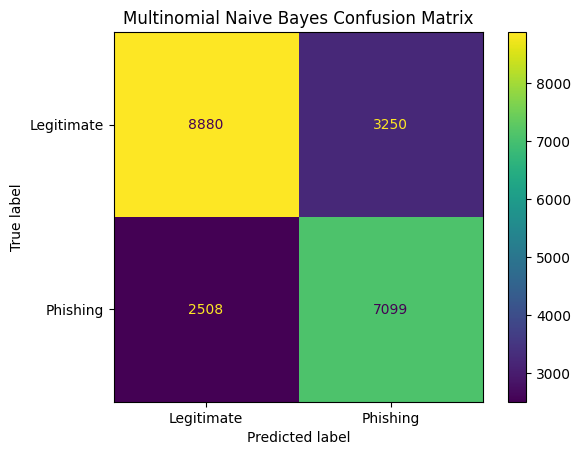

In [ ]:
cm = confusion_matrix(y_test, y_pred)

display = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Legitimate", "Phishing"]
)

display.plot()
plt.title("Multinomial Naive Bayes Confusion Matrix")
plt.show()

Look at incorrect predictions

In [ ]:
results = pd.DataFrame({
    "Email": X_test.values,
    "Actual": y_test.values,
    "Predicted": y_pred
})

errors = results[
    results["Actual"] != results["Predicted"]
]

print("Number of errors:", len(errors))

errors.head()

Number of errors: 5758


,Email,Actual,Predicted
0,Hello there! So what is up my sister? Did you...,0,1
2,Robotics Are Havesting Minerals A unique compa...,1,0
7,ERV Notification: ([ORGANIZATION] - [DATE]) T...,0,1
24,END OF YEAR LOTTERY AWARD NOTIFICATION. [ORGAN...,1,0
26,"[Mhln] in inefficient this molar ""But, my dear...",1,0


Print example mistakes: False Positives (legitimate emails flagged as phishing emails)

In [ ]:
false_positives = results[
    (results["Actual"] == 0) &
    (results["Predicted"] == 1)
]

false_positives.head(5)

,Email,Actual,Predicted
0,Hello there! So what is up my sister? Did you...,0,1
7,ERV Notification: ([ORGANIZATION] - [DATE]) T...,0,1
34,Re: Request for help in checking GPL-compatibi...,0,1
39,deal to be flipped out of [ORGANIZATION] book ...,0,1
47,Re: [[ORGANIZATION]] Creative Commons Namespac...,0,1


Print example mistakes: False Negatives (phishing emails flagged as legitimate emails)

In [ ]:
false_negatives = results[
    (results["Actual"] == 1) &
    (results["Predicted"] == 0)
]

false_negatives.head(5)

,Email,Actual,Predicted
2,Robotics Are Havesting Minerals A unique compa...,1,0
24,END OF YEAR LOTTERY AWARD NOTIFICATION. [ORGAN...,1,0
26,"[Mhln] in inefficient this molar ""But, my dear...",1,0
28,"Learn Technical Analysis June 11-12, Houston ...",1,0
31,The00-//Basta-de-Pagar-de-Mas !! satellite def...,1,0


# Testing on new emails

In [ ]:
import re
import string
from urllib.parse import urlparse
from collections import Counter
from scipy.sparse import hstack

In [206]:

def predict_email(
    subject,
    body,
    sender_domain="",
    attachment_count=0
):

    email_text = subject + " " + body

    # TF-IDF
    email_vector = vectorizer.transform([email_text])

    # EXISTING ENGINEERED FEATURES

    sender_domain_length = len(sender_domain)

    subject_length = len(subject)

    body_length = len(body)

    email_length = len(email_text)

    punctuation_count = sum(
        c in string.punctuation
        for c in email_text
    )

    words = email_text.lower().split()

    if len(words) > 0:
        word_frequency = Counter(words).most_common(1)[0][1]
    else:
        word_frequency = 0

    # URL FEATURES

    urls = re.findall(r'https?://\S+|www\.\S+', email_text)

    url_count = len(urls)

    if url_count > 0:

        url_lengths = [len(url) for url in urls]

        url_length_avg = sum(url_lengths) / url_count

        subdomains = []

        for url in urls:

            hostname = urlparse(url).hostname

            if hostname:

                subdomains.append(
                    max(len(hostname.split(".")) - 2, 0)
                )

        if len(subdomains) > 0:
            url_subdom_avg = sum(subdomains) / len(subdomains)
        else:
            url_subdom_avg = 0

    else:

        url_length_avg = 0
        url_subdom_avg = 0

    # COMBINE

    numeric_values = [[
        sender_domain_length,
        subject_length,
        body_length,
        email_length,
        punctuation_count,
        word_frequency,
        url_count,
        url_length_avg,
        url_subdom_avg,
        attachment_count
    ]]

    email_vector = hstack([
        email_vector,
        numeric_values
    ])

    # PREDICT

    prediction = model.predict(email_vector)[0]

    probability = model.predict_proba(email_vector)

    print("Legitimate probability:", round(probability[0][0],4))
    print("Phishing probability:", round(probability[0][1],4))

    print()

    if prediction == 1:

        print("Prediction: Phishing")
        print(f"Confidence: {probability[0][1]*100:.2f}%")

    else:

        print("Prediction: Legitimate")
        print(f"Confidence: {probability[0][0]*100:.2f}%")

## Legitimate Email Example #1

In [ ]:
predict_email(
    subject="Weekly Project Meeting",
    body="""
Hi everyone,

Just a reminder that our weekly project meeting will be tomorrow at 2:00 PM in Conference Room B.

Please review the agenda before the meeting and let me know if you'd like to add any discussion topics.

Thanks,
Sarah
""",
    sender_domain="company.com",
    attachment_count=1
)

Legitimate probability: 0.9997
Phishing probability: 0.0003

Prediction: Legitimate
Confidence: 99.97%


## Phishing Email Example #1



In [ ]:
predict_email(
    subject="URGENT: Verify Your Account Immediately",
    body="""
Your online banking account has been temporarily suspended.

Please verify your identity immediately using the secure link below.

https://secure-login-update.verify-account-login.com

Failure to verify your account within 24 hours will permanently disable your account.

Thank you.
""",
    sender_domain="verify-account-login.com",
    attachment_count=0
)

Legitimate probability: 0.0
Phishing probability: 1.0

Prediction: Phishing
Confidence: 100.00%
